In [3]:
import os
import sys
import pandas as pd
import numpy as np
import glob
import time
#import gget
import scipy
from scipy.sparse import csr_matrix
import anndata as an
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import random
from importlib import reload
import warnings
import ot
from scipy.spatial.distance import pdist, squareform
from matplotlib.colors import ListedColormap
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from kneed import KneeLocator  # pip install kneed

"""WARNING: no warnings"""
warnings.filterwarnings("ignore")

source_path = os.path.abspath("../utilities/")
sys.path.append(source_path)
import matrix as matrix
source_path = os.path.abspath("../utilities/calculations/")
sys.path.append(source_path)
import centrality as central

In [5]:
anndata_path    = "/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/anndata/"
population_path = anndata_path + "population_mESC_1000000_features.h5ad"
singlecell_path = anndata_path + "singlecell_mESC_1000000_features.h5ad"

t0 = time.time(); adata = sc.read_h5ad(population_path)
print(f"Population loaded in {time.time()-t0:.1f}s"); sc.logging.print_memory_usage()

t0 = time.time(); bdata = sc.read_h5ad(singlecell_path)
print(f"Single-cell loaded in {time.time()-t0:.1f}s"); sc.logging.print_memory_usage()

CN     = pd.read_csv("centrality_core/core_nodes.csv")
CE     = pd.read_csv("centrality_core/core_edges.csv")
H_core = sp.load_npz("centrality_core/H_core.npz")
print(f"\nCN: {len(CN)} core nodes  |  CE: {len(CE)} core edges  |  H_core: {H_core.shape}")

Population loaded in 18.9s
Memory usage: current 28.90 GB, difference -0.50 GB
Single-cell loaded in 240.4s
Memory usage: current 29.29 GB, difference +0.38 GB

CN: 467 core nodes  |  CE: 62447 core edges  |  H_core: (467, 62447)


In [6]:
def find_outliers_iqr(col):
    Q1, Q3 = col.quantile(0.15), col.quantile(0.85)
    IQR = Q3 - Q1
    return (col < Q1 - 1.5*IQR) | (col > Q3 + 1.5*IQR)

adata.obs['degree_outlier'] = find_outliers_iqr(adata.obs['degree'])
outliers = adata.obs[adata.obs['degree_outlier']].index.to_list()
print(f"Outlier loci: {len(outliers)}")

#matrix.expand_and_normalize_anndata(adata, oe_kr=False)

shared_loci = adata.obs_names

Outlier loci: 148


In [7]:
N_CELLS  = 5
cell_ids = list(bdata.var['basename'].unique())[:N_CELLS]

incidence_matrices = {}
for i, cell_id in enumerate(cell_ids):
    sc_data = bdata[:, bdata.var['basename'] == cell_id].copy()
    H_o = sc_data.to_df()
    H_o = H_o.T.drop_duplicates().T
    H_o.columns = [f"{cell_id}_{x}" for x in H_o.columns]
    incidence_matrices[cell_id] = H_o
    print(f"  {i+1}/{N_CELLS}  {cell_id}")

  1/5  o3b96
  2/5  o3b43
  3/5  o4b84
  4/5  o3b30
  5/5  o3b55


In [8]:
_A0 = matrix.clique_expand_incidence(incidence_matrices[cell_ids[0]], zero_diag=False)
_A0 = _A0.reindex(index=shared_loci, columns=shared_loci).fillna(0)
_A0 = _A0.drop([o for o in outliers if o in _A0.index], axis=0)\
         .drop([o for o in outliers if o in _A0.columns], axis=1)
locus_index = _A0.index

cn_bins        = set(CN["bin_name"].values)
core_mask      = np.array([b in cn_bins for b in locus_index])
core_positions = np.where(core_mask)[0]
print(f"Loci: {len(locus_index)}  |  Core nodes mapped: {core_mask.sum()}")

Loci: 2431  |  Core nodes mapped: 467


In [9]:
CMAP = "Reds"

def get_clique_matrix(cell_id):
    A = matrix.clique_expand_incidence(incidence_matrices[cell_id], zero_diag=False)
    A = A.reindex(index=shared_loci, columns=shared_loci).fillna(0)
    A = A.drop([o for o in outliers if o in A.index], axis=0)\
         .drop([o for o in outliers if o in A.columns], axis=1)
    return np.log1p(A.values)

In [10]:
A_core_dense = np.asarray((H_core @ H_core.T).todense())

n = len(locus_index)
core_overlay = np.zeros((n, n))
core_overlay[np.ix_(core_positions, core_positions)] = A_core_dense
core_overlay = np.ma.masked_where(core_overlay == 0, core_overlay)
print(f"Core overlay shape: {core_overlay.shape}  |  Non-zero entries: {(~core_overlay.mask).sum()}")

Core overlay shape: (2431, 2431)  |  Non-zero entries: 91791


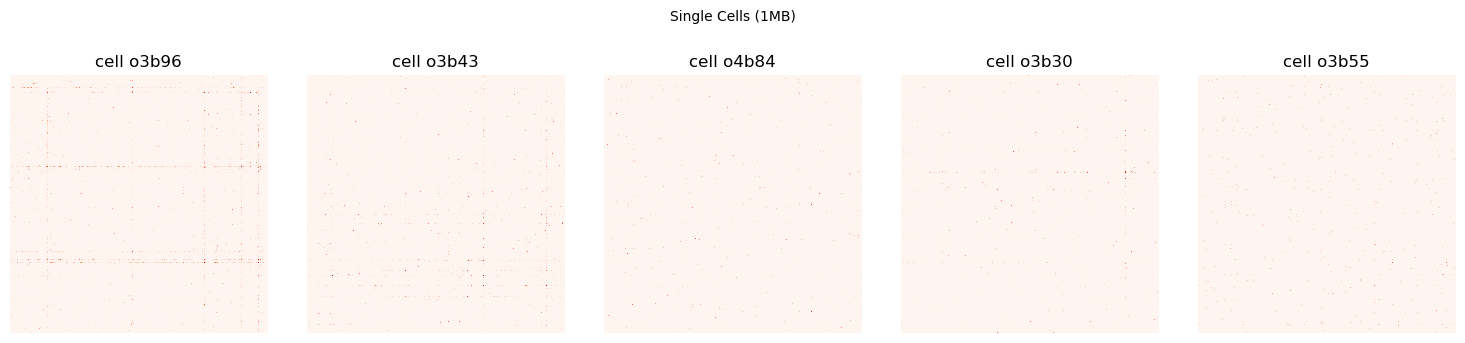

In [13]:
n_cols, n_rows = 5, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
axes = axes.flatten()

for ax, cell_id in zip(axes, cell_ids):
    sns.heatmap(get_clique_matrix(cell_id), cmap=CMAP, square=True, cbar=False, ax=ax, rasterized=True)
    ax.set(xticks=[], yticks=[], title=f"cell {cell_id}", xlabel="", ylabel="")

for ax in axes[N_CELLS:]:
    ax.set_visible(False)

fig.suptitle(f"Single Cells (1MB)", y=1.01, fontsize=10)
plt.tight_layout()
plt.show()

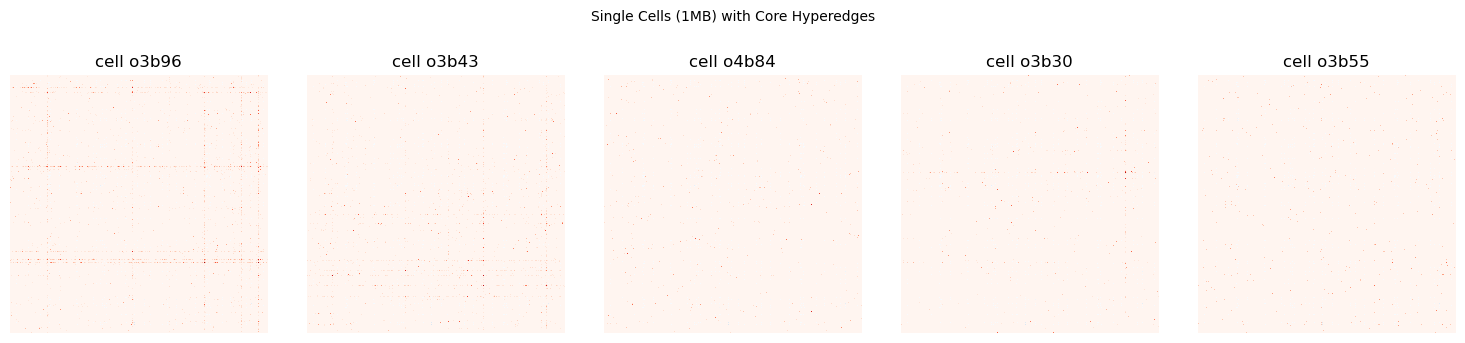

In [14]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
axes = axes.flatten()

for ax, cell_id in zip(axes, cell_ids):
    A = get_clique_matrix(cell_id)

    sns.heatmap(A, cmap=CMAP, square=True, cbar=False, ax=ax, rasterized=True)
    ax.set(xticks=[], yticks=[], title=f"cell {cell_id}", xlabel="", ylabel="")

    ax.pcolormesh(core_overlay, cmap="Blues", vmin=0, alpha=0.9, zorder=3, rasterized=True)

for ax in axes[N_CELLS:]:
    ax.set_visible(False)

fig.suptitle(f"Single Cells (1MB) with Core Hyperedges", y=1.01, fontsize=10)
plt.tight_layout()
plt.show()